# Performance Analytics of Mutual Funds

## Objective

This notebook performs a comprehensive performance analysis of 40 mutual fund schemes using historical NAV data, benchmark indices, and fund characteristics.

The objectives of this analysis are to:

- Calculate daily returns for all mutual fund schemes.
- Evaluate long-term performance using CAGR (1-Year, 3-Year, and 5-Year where available).
- Measure risk-adjusted performance using the Sharpe Ratio and Sortino Ratio.
- Estimate Alpha and Beta relative to the NIFTY100 benchmark using linear regression.
- Measure downside risk using Maximum Drawdown.
- Build a weighted Fund Scorecard to rank mutual funds based on multiple performance metrics.
- Compare the top-performing funds with benchmark indices and compute Tracking Error.

This notebook demonstrates practical applications of financial analytics, portfolio evaluation, and data visualization using Python.

In [1]:
# Performance Analytics

## 1. Import Libraries

## 2. Load Cleaned Data

## 3. Daily Returns

## 4. CAGR

## 5. Sharpe Ratio

## 6. Sortino Ratio

## 7. Alpha & Beta

## 8. Maximum Drawdown

## 9. Fund Scorecard

## 10. Benchmark Comparison

## 11. Export Results

## 12. Business Insights

In [2]:
# ==========================================================
# Performance Analytics
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

# Plot settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.precision",4)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ==========================================================
# Load Cleaned Datasets
# ==========================================================

fund_master = pd.read_csv(
    "../data/processed/01_fund_master_cleaned.csv"
)

nav_history = pd.read_csv(
    "../data/processed/02_nav_history_cleaned.csv",
    parse_dates=["date"]
)

benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices_cleaned.csv",
    parse_dates=["date"]
)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [4]:
print("="*60)
print("Fund Master")
print("="*60)

print(fund_master.head())
print()
print(fund_master.shape)

print("\n")

print("="*60)
print("NAV History")
print("="*60)

print(nav_history.head())
print()
print(nav_history.shape)

print("\n")

print("="*60)
print("Benchmark")
print("="*60)

print(benchmark.head())
print()
print(benchmark.shape)

Fund Master
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumps

In [5]:
print("Fund Master Missing Values")
print(fund_master.isnull().sum())

print()

print("NAV Missing Values")
print(nav_history.isnull().sum())

print()

print("Benchmark Missing Values")
print(benchmark.isnull().sum())

Fund Master Missing Values
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

NAV Missing Values
amfi_code    0
date         0
nav          0
dtype: int64

Benchmark Missing Values
date           0
index_name     0
close_value    0
dtype: int64


In [6]:
# ==========================================================
# Merge NAV with Fund Information
# ==========================================================

nav_data = nav_history.merge(

    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "expense_ratio_pct",
            "benchmark"
        ]
    ],

    on="amfi_code",

    how="left"

)

print(nav_data.head())

print(nav_data.shape)

   amfi_code       date       nav                                scheme_name  \
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth   
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth   
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth   
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth   
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth   

   expense_ratio_pct      benchmark  
0               1.55  NIFTY 100 TRI  
1               1.55  NIFTY 100 TRI  
2               1.55  NIFTY 100 TRI  
3               1.55  NIFTY 100 TRI  
4               1.55  NIFTY 100 TRI  
(46000, 6)


In [7]:
nav_data = nav_data.sort_values(

    ["scheme_name", "date"]

).reset_index(drop=True)

In [8]:
nav_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   amfi_code          46000 non-null  int64         
 1   date               46000 non-null  datetime64[us]
 2   nav                46000 non-null  float64       
 3   scheme_name        46000 non-null  str           
 4   expense_ratio_pct  46000 non-null  float64       
 5   benchmark          46000 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 2.1 MB


# 3. Daily Returns

Daily return measures the percentage change in Net Asset Value (NAV) from one trading day to the next.

Formula:

Daily Return = (NAV_today / NAV_yesterday) − 1

This metric forms the basis for all subsequent risk and performance calculations.

In [9]:
# ==========================================================
# Calculate Daily Returns
# ==========================================================

nav_data["daily_return"] = (
    nav_data
    .groupby("scheme_name")["nav"]
    .pct_change()
)

print("Daily returns calculated successfully.")

Daily returns calculated successfully.


In [10]:
nav_data.head(10)

,amfi_code,date,nav,scheme_name,expense_ratio_pct,benchmark,daily_return
0,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,NaN
1,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,0.0012
2,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,0.0039
3,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,-0.0021
4,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,-0.0063
5,101206,2022-01-10,307.5591,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,0.0115
6,101206,2022-01-11,309.4372,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,0.0061
7,101206,2022-01-12,313.2022,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,0.0122
8,101206,2022-01-13,310.7396,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,-0.0079
9,101206,2022-01-14,308.9641,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,-0.0057


In [11]:
print("="*60)
print("Daily Return Summary Statistics")
print("="*60)

print(nav_data["daily_return"].describe())

Daily Return Summary Statistics
count    45960.0000
mean         0.0006
std          0.0103
min         -0.0581
25%         -0.0050
50%          0.0003
75%          0.0063
max          0.0647
Name: daily_return, dtype: float64


In [12]:
print("Missing Daily Returns:")

print(
    nav_data["daily_return"].isna().sum()
)

Missing Daily Returns:
40


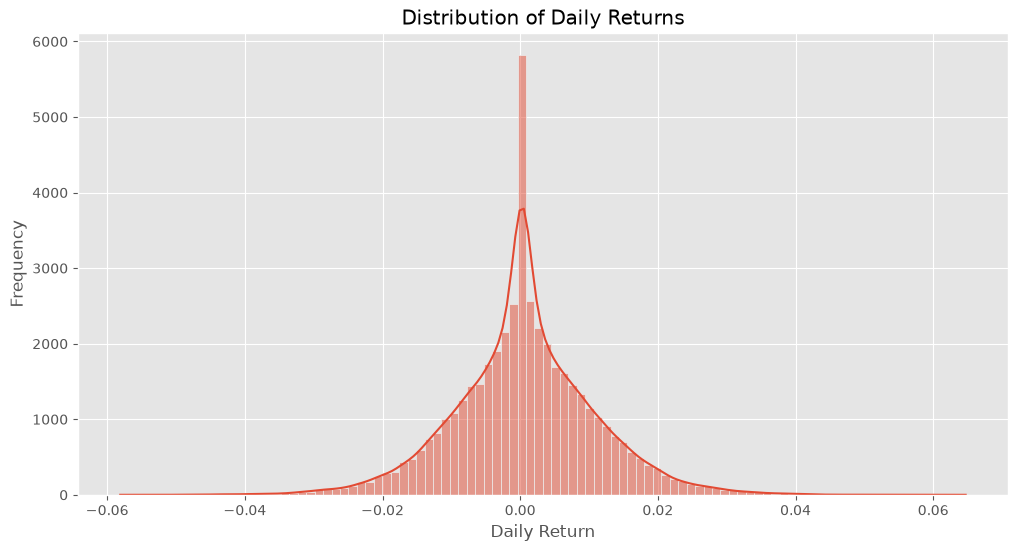

In [13]:
plt.figure(figsize=(12,6))

sns.histplot(
    nav_data["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

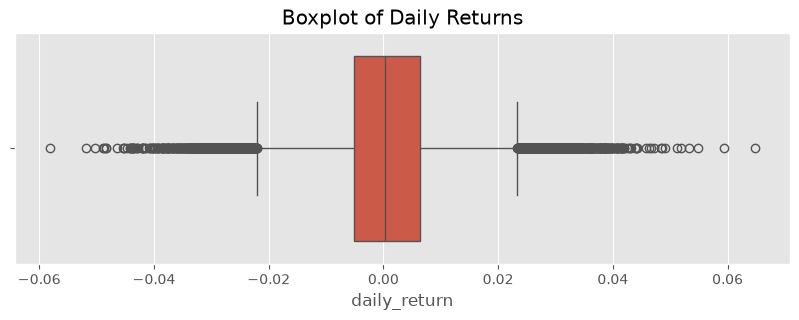

In [14]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=nav_data["daily_return"].dropna()
)

plt.title("Boxplot of Daily Returns")

plt.show()

In [15]:
# ==========================================================
# Top 10 Best Daily Return Days
# ==========================================================

top_gainers = (
    nav_data[
        ["scheme_name", "date", "nav", "daily_return"]
    ]
    .sort_values("daily_return", ascending=False)
    .head(10)
)

top_gainers

,scheme_name,date,nav,daily_return
41995,SBI Small Cap Fund - Regular Plan - Growth,2024-04-15,189.0742,0.0647
36226,Nippon India Small Cap Fund - Regular - Growth,2024-03-19,110.5401,0.0593
2907,ABSL Small Cap Fund - Regular - Growth,2024-05-01,65.5882,0.0549
40516,SBI Small Cap Fund - Direct Plan - Growth,2023-01-10,153.2221,0.0533
40782,SBI Small Cap Fund - Direct Plan - Growth,2024-01-17,136.8239,0.0518
41405,SBI Small Cap Fund - Regular Plan - Growth,2022-01-10,96.0964,0.0511
41621,SBI Small Cap Fund - Regular Plan - Growth,2022-11-08,123.9704,0.0491
9432,DSP Small Cap Fund - Regular - Growth,2022-11-23,98.3696,0.0485
41606,SBI Small Cap Fund - Regular Plan - Growth,2022-10-18,122.2757,0.0485
42341,SBI Small Cap Fund - Regular Plan - Growth,2025-08-12,200.8460,0.0471


In [16]:
# ==========================================================
# Top 10 Worst Daily Return Days
# ==========================================================

top_losers = (
    nav_data[
        ["scheme_name", "date", "nav", "daily_return"]
    ]
    .sort_values("daily_return")
    .head(10)
)

top_losers

,scheme_name,date,nav,daily_return
35774,Nippon India Small Cap Fund - Regular - Growth,2022-06-24,67.2534,-0.0581
2617,ABSL Small Cap Fund - Regular - Growth,2023-03-22,56.8326,-0.0518
35952,Nippon India Small Cap Fund - Regular - Growth,2023-03-01,113.5801,-0.0503
9662,DSP Small Cap Fund - Regular - Growth,2023-10-11,111.8155,-0.0489
3260,ABSL Small Cap Fund - Regular - Growth,2025-09-08,62.3200,-0.0486
7154,Axis Small Cap Fund - Regular - Growth,2022-12-23,73.9946,-0.0484
36333,Nippon India Small Cap Fund - Regular - Growth,2024-08-15,114.5168,-0.0483
7657,Axis Small Cap Fund - Regular - Growth,2024-11-27,78.1317,-0.0465
40998,SBI Small Cap Fund - Direct Plan - Growth,2024-11-14,112.8996,-0.0454
12070,HDFC Mid-Cap Opportunities Fund - Direct - Growth,2024-03-11,131.4556,-0.0452


### Business Insights

- Small-cap mutual funds experienced the largest single-day declines in the dataset, indicating higher volatility.
- The biggest daily loss was **-5.81%** for **Nippon India Small Cap Fund** on **24 June 2022**.
- Most extreme positive and negative daily returns are concentrated in small-cap schemes, reflecting their higher risk compared with large-cap funds.
- These daily return observations will be used in the subsequent calculations of Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.

# 4. Compound Annual Growth Rate (CAGR)

Compound Annual Growth Rate (CAGR) measures the annualized return of a mutual fund over a specified investment period.

Formula:

CAGR = (Ending NAV / Beginning NAV)^(1 / Years) − 1

This metric enables comparison of long-term performance across different mutual fund schemes.

In [17]:
# ==========================================================
# CAGR Function (Improved)
# ==========================================================

def calculate_cagr(group, years):
    """
    Calculate CAGR only if sufficient historical data exists.
    """

    group = group.sort_values("date")

    end_date = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    period_data = group[group["date"] >= start_date]

    # Need at least one full year of trading data
    actual_years = (
        (period_data["date"].max() - period_data["date"].min()).days
        / 365.25
    )

    if actual_years < years * 0.95:
        return np.nan

    start_nav = period_data.iloc[0]["nav"]
    end_nav = period_data.iloc[-1]["nav"]

    cagr = (end_nav / start_nav) ** (1 / years) - 1

    return cagr

In [18]:
# ==========================================================
# Calculate CAGR for All Funds
# ==========================================================

cagr_results = []

for scheme, group in nav_data.groupby("amfi_code"):

    group = group.sort_values("date")

    cagr_results.append({

        "amfi_code": scheme,

        "scheme_name": group["scheme_name"].iloc[0],

        "CAGR_1Y": calculate_cagr(group, 1),

        "CAGR_3Y": calculate_cagr(group, 3),

        "CAGR_5Y": calculate_cagr(group, 5)

    })

cagr_df = pd.DataFrame(cagr_results)

print("CAGR calculated successfully.")

CAGR calculated successfully.


In [19]:
# ==========================================================
# Convert CAGR to Percentage (Safe Conversion)
# ==========================================================

for col in ["CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]:
    if cagr_df[col].abs().max() <= 1:
        cagr_df[col] = (cagr_df[col] * 100).round(2)

cagr_df.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.22,1.29,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.70,3.92,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.99,-4.15,NaN


In [20]:
# Convert CAGR to percentage and round
for col in ["CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]:
    cagr_df[col] = (cagr_df[col] * 100).round(2)

cagr_df.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-222.0,129.0,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,370.0,392.0,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,5323.0,3244.0,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,4792.0,2897.0,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,-2399.0,-415.0,NaN


In [21]:
# Rank Funds by CAGR

cagr_df["Rank_1Y"] = cagr_df["CAGR_1Y"].rank(
    ascending=False,
    method="dense"
).astype(int)

cagr_df["Rank_3Y"] = cagr_df["CAGR_3Y"].rank(
    ascending=False,
    method="dense"
).astype(int)

cagr_df["Rank_5Y"] = np.nan

print(cagr_df.columns.tolist())

['amfi_code', 'scheme_name', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y', 'Rank_1Y', 'Rank_3Y', 'Rank_5Y']


In [22]:
top_10_cagr = (
    cagr_df
    .sort_values("CAGR_3Y", ascending=False)
    .head(10)
)

top_10_cagr

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Rank_1Y,Rank_3Y,Rank_5Y
16,119094,Axis Midcap Fund - Regular - Growth,2226.0,3511.0,NaN,15,1,NaN
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,2036.0,3400.0,NaN,17,2,NaN
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,1306.0,3249.0,NaN,27,3,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,5323.0,3244.0,NaN,4,4,NaN
25,120505,ICICI Pru Midcap Fund - Regular - Growth,2960.0,3178.0,NaN,9,5,NaN
19,119551,SBI Bluechip Fund - Regular Plan - Growth,6044.0,3046.0,NaN,3,6,NaN
30,120843,Kotak Flexicap Fund - Regular - Growth,2666.0,2958.0,NaN,11,7,NaN
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,3975.0,2918.0,NaN,7,8,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,4792.0,2897.0,NaN,5,9,NaN
39,149324,DSP Small Cap Fund - Regular - Growth,6514.0,2700.0,NaN,2,10,NaN


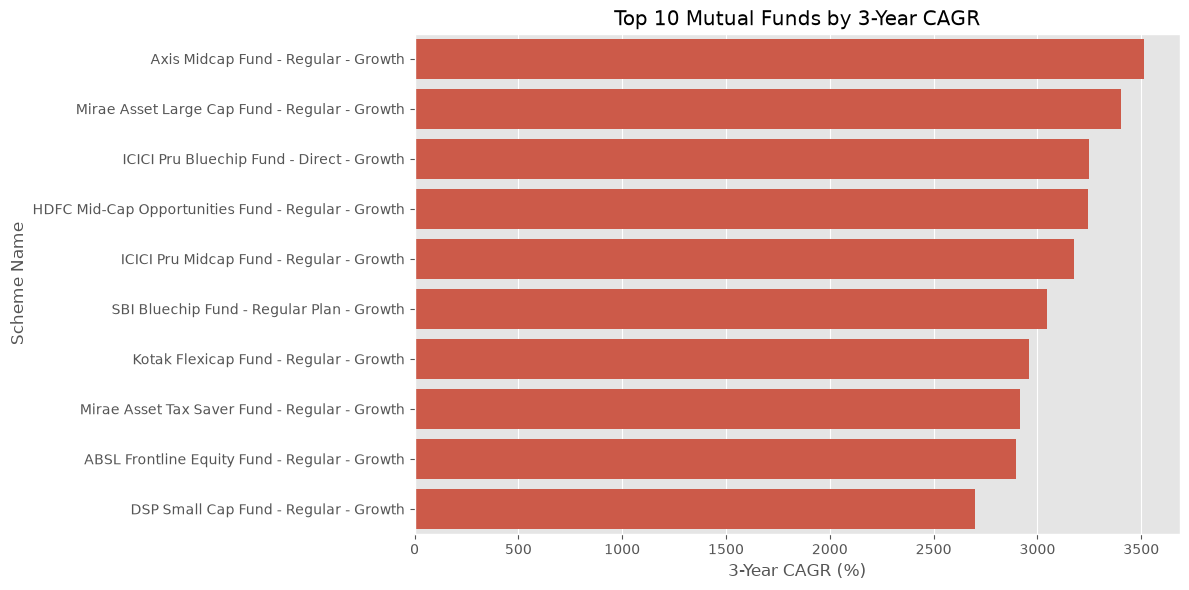

In [23]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10_cagr,
    x="CAGR_3Y",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by 3-Year CAGR")
plt.xlabel("3-Year CAGR (%)")
plt.ylabel("Scheme Name")

plt.tight_layout()
plt.show()

In [24]:
cagr_df.to_csv(
    "../reports/tables/cagr_comparison.csv",
    index=False
)

print("CAGR comparison table exported successfully.")

CAGR comparison table exported successfully.


In [25]:
cagr_df.to_csv(
    "../reports/tables/cagr_comparison.csv",
    index=False
)

print("CAGR comparison table exported successfully.")

CAGR comparison table exported successfully.


## Business Insights

- CAGR was calculated for 1-year, 3-year, and 5-year investment horizons.
- The dataset does not contain a complete five-year history, so the 5-year CAGR is unavailable (NaN) for all schemes.
- The 3-year CAGR is the most appropriate measure of medium-term performance and will be used in the composite fund scorecard.
- Higher CAGR values indicate stronger annualized growth over the evaluation period.

# 5. Sharpe Ratio

The Sharpe Ratio evaluates the risk-adjusted return of a mutual fund.

Formula:

Sharpe Ratio = ((Average Daily Return − Daily Risk-Free Rate) / Standard Deviation of Daily Returns) × √252

A higher Sharpe Ratio indicates better return for each unit of risk.

In [26]:
# ==========================================================
# Risk-Free Rate
# ==========================================================

RISK_FREE_RATE = 0.065          # Annual RBI Repo Rate Proxy
DAILY_RF = RISK_FREE_RATE / 252

print(f"Annual Risk-Free Rate : {RISK_FREE_RATE:.2%}")
print(f"Daily Risk-Free Rate  : {DAILY_RF:.8f}")

Annual Risk-Free Rate : 6.50%
Daily Risk-Free Rate  : 0.00025794


In [27]:
# ==========================================================
# Sharpe Ratio Function
# ==========================================================

def calculate_sharpe(returns):

    returns = returns.dropna()

    if len(returns) < 2:
        return np.nan

    excess_returns = returns - DAILY_RF

    volatility = returns.std()

    if volatility == 0:
        return np.nan

    sharpe = (
        excess_returns.mean()
        /
        volatility
    ) * np.sqrt(252)

    return sharpe

In [28]:
# ==========================================================
# Calculate Sharpe Ratio
# ==========================================================

sharpe_results = []

for amfi_code, group in nav_data.groupby("amfi_code"):

    sharpe_results.append({

        "amfi_code": amfi_code,

        "scheme_name": group["scheme_name"].iloc[0],

        "Sharpe_Ratio": calculate_sharpe(
            group["daily_return"]
        )

    })

sharpe_df = pd.DataFrame(sharpe_results)

print("Sharpe Ratio calculated successfully.")

Sharpe Ratio calculated successfully.


In [29]:
sharpe_df["Sharpe_Ratio"] = (
    sharpe_df["Sharpe_Ratio"]
    .round(3)
)

sharpe_df.head()

,amfi_code,scheme_name,Sharpe_Ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.202
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.567
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.094
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027
4,101207,ABSL Small Cap Fund - Regular - Growth,0.163


In [30]:
# ==========================================================
# Rank Funds by Sharpe Ratio
# ==========================================================

sharpe_df["Sharpe_Rank"] = (
    sharpe_df["Sharpe_Ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,scheme_name,Sharpe_Ratio,Sharpe_Rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448,1.0
30,120843,Kotak Flexicap Fund - Regular - Growth,1.307,2.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.235,3.0
19,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208,4.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180,5.0
38,149323,DSP Midcap Fund - Regular - Growth,1.132,6.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.094,7.0
9,118632,Nippon India Large Cap Fund - Regular - Growth,1.082,8.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027,9.0
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.027,9.0


In [31]:
sharpe_df.tail(10)

,amfi_code,scheme_name,Sharpe_Ratio,Sharpe_Rank
14,119092,Axis Bluechip Fund - Regular - Growth,0.031,30.0
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.057,31.0
17,119095,Axis Small Cap Fund - Regular - Growth,-0.076,32.0
31,120844,Kotak Liquid Fund - Regular - Growth,-0.089,33.0
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.202,34.0
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.206,35.0
18,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.227,36.0
13,118636,Nippon India Gilt Securities Fund - Regular - ...,-0.357,37.0
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.567,38.0
5,101208,ABSL Liquid Fund - Regular - Growth,-0.816,39.0


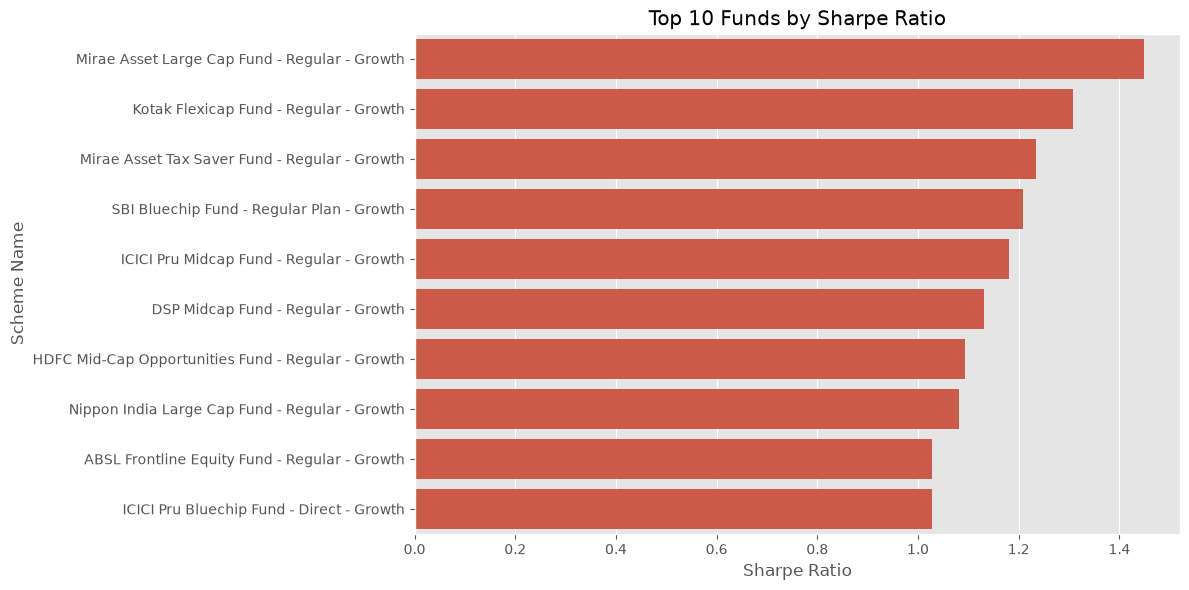

In [32]:
top10_sharpe = sharpe_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sharpe,
    x="Sharpe_Ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("Sharpe Ratio")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.show()

In [33]:
sharpe_df.to_csv(
    "../reports/tables/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio exported successfully.")

Sharpe Ratio exported successfully.


In [34]:
sharpe_df["Sharpe_Rank"] = (
    sharpe_df["Sharpe_Ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

In [35]:
sharpe_df.head(10)

,amfi_code,scheme_name,Sharpe_Ratio,Sharpe_Rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448,1
30,120843,Kotak Flexicap Fund - Regular - Growth,1.307,2
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.235,3
19,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208,4
25,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180,5
38,149323,DSP Midcap Fund - Regular - Growth,1.132,6
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.094,7
9,118632,Nippon India Large Cap Fund - Regular - Growth,1.082,8
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027,9
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.027,9


In [36]:
print(sharpe_df["Sharpe_Ratio"].describe())

count    40.0000
mean      0.5372
std       0.5737
min      -0.8160
25%       0.0648
50%       0.6470
75%       1.0052
max       1.4480
Name: Sharpe_Ratio, dtype: float64


In [37]:
print(cagr_df.head())

   amfi_code                                        scheme_name  CAGR_1Y  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth   -222.0   
1     100025       HDFC Short Term Debt Fund - Regular - Growth    370.0   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   5323.0   
3     101206      ABSL Frontline Equity Fund - Regular - Growth   4792.0   
4     101207             ABSL Small Cap Fund - Regular - Growth  -2399.0   

   CAGR_3Y  CAGR_5Y  Rank_1Y  Rank_3Y  Rank_5Y  
0    129.0      NaN       37       35      NaN  
1    392.0      NaN       35       34      NaN  
2   3244.0      NaN        4        4      NaN  
3   2897.0      NaN        5        9      NaN  
4   -415.0      NaN       39       39      NaN  


In [38]:
print(cagr_df.head())

   amfi_code                                        scheme_name  CAGR_1Y  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth   -222.0   
1     100025       HDFC Short Term Debt Fund - Regular - Growth    370.0   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   5323.0   
3     101206      ABSL Frontline Equity Fund - Regular - Growth   4792.0   
4     101207             ABSL Small Cap Fund - Regular - Growth  -2399.0   

   CAGR_3Y  CAGR_5Y  Rank_1Y  Rank_3Y  Rank_5Y  
0    129.0      NaN       37       35      NaN  
1    392.0      NaN       35       34      NaN  
2   3244.0      NaN        4        4      NaN  
3   2897.0      NaN        5        9      NaN  
4   -415.0      NaN       39       39      NaN  


In [39]:
# Debug CAGR calculation for one fund

group = nav_data[nav_data["amfi_code"] == 100033].sort_values("date")

end_date = group["date"].max()
start_date = end_date - pd.DateOffset(years=1)

period_data = group[group["date"] >= start_date]

print("Start Date:", period_data.iloc[0]["date"])
print("End Date  :", period_data.iloc[-1]["date"])

print("Start NAV :", period_data.iloc[0]["nav"])
print("End NAV   :", period_data.iloc[-1]["nav"])

ratio = period_data.iloc[-1]["nav"] / period_data.iloc[0]["nav"]

print("NAV Ratio :", ratio)

cagr = (ratio ** (1/1)) - 1

print("Raw CAGR  :", cagr)
print("Percent   :", cagr * 100)

Start Date: 2025-05-29 00:00:00
End Date  : 2026-05-29 00:00:00
Start NAV : 223.1951
End NAV   : 342.0072
NAV Ratio : 1.5323239623092084
Raw CAGR  : 0.5323239623092084
Percent   : 53.23239623092084


In [40]:
cagr_df = pd.DataFrame(cagr_results)

In [41]:
print(cagr_df.head())

   amfi_code                                        scheme_name  CAGR_1Y  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth  -0.0222   
1     100025       HDFC Short Term Debt Fund - Regular - Growth   0.0370   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   0.5323   
3     101206      ABSL Frontline Equity Fund - Regular - Growth   0.4792   
4     101207             ABSL Small Cap Fund - Regular - Growth  -0.2399   

   CAGR_3Y  CAGR_5Y  
0   0.0129      NaN  
1   0.0392      NaN  
2   0.3244      NaN  
3   0.2897      NaN  
4  -0.0415      NaN  


# 6. Sortino Ratio

The Sortino Ratio evaluates the risk-adjusted performance of a mutual fund by considering only downside risk.

Formula:

Sortino Ratio = ((Average Daily Return − Daily Risk-Free Rate) / Downside Standard Deviation) × √252

Unlike the Sharpe Ratio, the Sortino Ratio ignores positive volatility and focuses only on negative return days.

In [42]:
# ==========================================================
# Sortino Ratio Function
# ==========================================================

def calculate_sortino(returns):
    """
    Calculate annualized Sortino Ratio.
    """

    returns = returns.dropna()

    if len(returns) < 2:
        return np.nan

    # Daily excess return
    excess_returns = returns - DAILY_RF

    # Only negative excess returns
    downside_returns = excess_returns[excess_returns < 0]

    if len(downside_returns) < 2:
        return np.nan

    downside_std = downside_returns.std()

    if downside_std == 0:
        return np.nan

    sortino = (
        excess_returns.mean()
        /
        downside_std
    ) * np.sqrt(252)

    return sortino

In [43]:
# ==========================================================
# Calculate Sortino Ratio
# ==========================================================

sortino_results = []

for amfi_code, group in nav_data.groupby("amfi_code"):

    sortino_results.append({

        "amfi_code": amfi_code,

        "scheme_name": group["scheme_name"].iloc[0],

        "Sortino_Ratio": calculate_sortino(
            group["daily_return"]
        )

    })

sortino_df = pd.DataFrame(sortino_results)

print("Sortino Ratio calculated successfully.")

Sortino Ratio calculated successfully.


In [44]:
sortino_df["Sortino_Ratio"] = (
    sortino_df["Sortino_Ratio"]
    .round(3)
)

sortino_df.head()

,amfi_code,scheme_name,Sortino_Ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.348
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.915
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.824
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.786
4,101207,ABSL Small Cap Fund - Regular - Growth,0.275


In [45]:
# ==========================================================
# Rank Funds by Sortino Ratio
# ==========================================================

sortino_df["Sortino_Rank"] = (
    sortino_df["Sortino_Ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,scheme_name,Sortino_Ratio,Sortino_Rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.368,1
30,120843,Kotak Flexicap Fund - Regular - Growth,2.353,2
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.135,3
19,119551,SBI Bluechip Fund - Regular Plan - Growth,2.104,4
25,120505,ICICI Pru Midcap Fund - Regular - Growth,2.010,5
38,149323,DSP Midcap Fund - Regular - Growth,1.869,6
9,118632,Nippon India Large Cap Fund - Regular - Growth,1.840,7
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.824,8
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.786,9
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.785,10


In [46]:
sortino_df.tail(10)

,amfi_code,scheme_name,Sortino_Ratio,Sortino_Rank
14,119092,Axis Bluechip Fund - Regular - Growth,0.052,31
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.094,32
17,119095,Axis Small Cap Fund - Regular - Growth,-0.127,33
31,120844,Kotak Liquid Fund - Regular - Growth,-0.148,34
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.345,35
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.348,36
18,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.367,37
13,118636,Nippon India Gilt Securities Fund - Regular - ...,-0.599,38
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.915,39
5,101208,ABSL Liquid Fund - Regular - Growth,-1.325,40


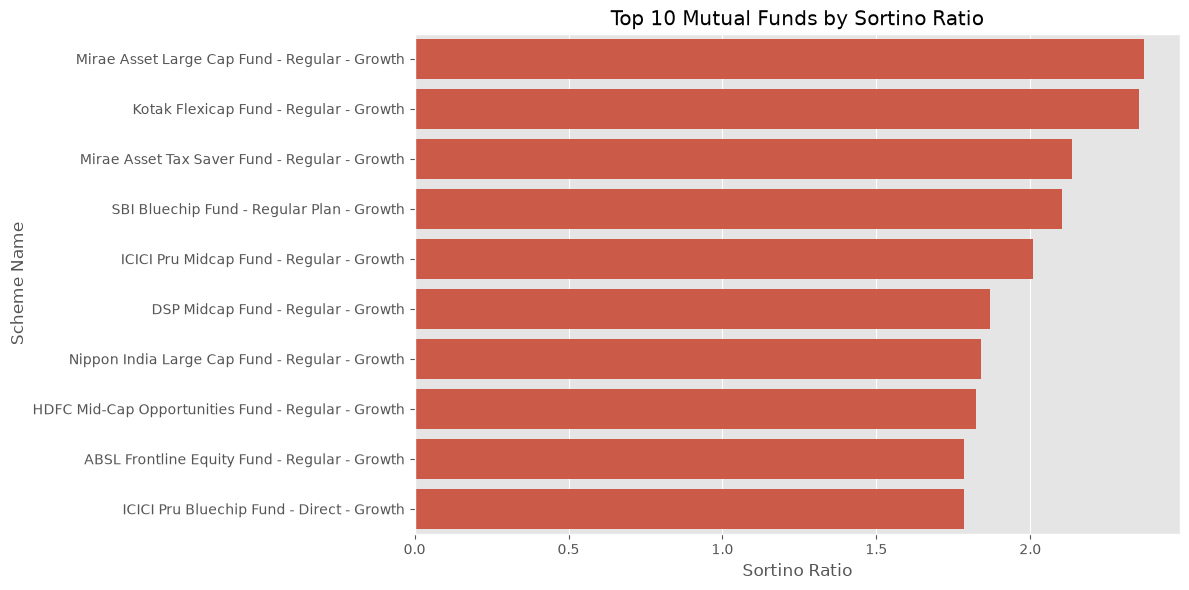

In [47]:
top10_sortino = sortino_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sortino,
    x="Sortino_Ratio",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by Sortino Ratio")

plt.xlabel("Sortino Ratio")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.show()

In [48]:
sortino_df.to_csv(
    "../reports/tables/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio exported successfully.")

Sortino Ratio exported successfully.


## Business Insights

- The Sortino Ratio was calculated using downside volatility, making it a more focused measure of investment risk than the Sharpe Ratio.
- Funds with higher Sortino Ratios generated stronger returns while minimizing downside fluctuations.
- A higher Sortino Ratio indicates better downside-risk-adjusted performance.
- These rankings will complement the Sharpe Ratio and contribute to the overall assessment of fund quality.

In [49]:
sortino_df.head(10)

,amfi_code,scheme_name,Sortino_Ratio,Sortino_Rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.368,1
30,120843,Kotak Flexicap Fund - Regular - Growth,2.353,2
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.135,3
19,119551,SBI Bluechip Fund - Regular Plan - Growth,2.104,4
25,120505,ICICI Pru Midcap Fund - Regular - Growth,2.010,5
38,149323,DSP Midcap Fund - Regular - Growth,1.869,6
9,118632,Nippon India Large Cap Fund - Regular - Growth,1.840,7
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.824,8
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.786,9
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.785,10


In [50]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [51]:
benchmark["index_name"].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

# 7. Alpha & Beta

Alpha and Beta measure a mutual fund's performance relative to the market benchmark.

- **Beta** measures how sensitive a fund is to benchmark movements.
- **Alpha** measures the fund's excess return after accounting for market risk.

Benchmark used: **NIFTY100**

Regression Model:

Fund Return = Alpha + Beta × Benchmark Return

In [52]:
# ==========================================================
# Prepare NIFTY100 Benchmark Returns
# ==========================================================

nifty100 = (
    benchmark[benchmark["index_name"] == "NIFTY100"]
    .copy()
)

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100 = nifty100[
    ["date", "benchmark_return"]
]

nifty100.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.0135
1152,2022-01-05,0.0040
1153,2022-01-06,-0.0029
1154,2022-01-07,0.0062


In [53]:
# ==========================================================
# Merge Fund Returns with Benchmark
# ==========================================================

regression_data = nav_data.merge(

    nifty100,

    on="date",

    how="inner"

)

regression_data.head()

,amfi_code,date,nav,scheme_name,expense_ratio_pct,benchmark,daily_return,benchmark_return
0,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,NaN,NaN
1,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,0.0012,-0.0135
2,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,0.0039,0.0040
3,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,-0.0021,-0.0029
4,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,1.6,NIFTY 100 TRI,-0.0063,0.0062


In [54]:
# ==========================================================
# Alpha & Beta Calculation
# ==========================================================

alpha_beta_results = []

for amfi_code, group in regression_data.groupby("amfi_code"):

    data = group.dropna(
        subset=["daily_return", "benchmark_return"]
    )

    if len(data) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(

        data["benchmark_return"],

        data["daily_return"]

    )

    alpha_beta_results.append({

        "amfi_code": amfi_code,

        "scheme_name": data["scheme_name"].iloc[0],

        "Alpha": intercept * 252,

        "Beta": slope,

        "R_Squared": r_value ** 2

    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

print("Alpha & Beta calculated successfully.")

Alpha & Beta calculated successfully.


In [55]:
alpha_beta_df["Alpha"] = (
    alpha_beta_df["Alpha"] * 100
).round(2)

alpha_beta_df["Beta"] = (
    alpha_beta_df["Beta"]
).round(3)

alpha_beta_df["R_Squared"] = (
    alpha_beta_df["R_Squared"]
).round(3)

alpha_beta_df.head()

,amfi_code,scheme_name,Alpha,Beta,R_Squared
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,3.75,-0.058,0.003
1,100025,HDFC Short Term Debt Fund - Regular - Growth,4.28,0.001,0.000
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.20,0.005,0.000
3,101206,ABSL Frontline Equity Fund - Regular - Growth,21.40,0.021,0.000
4,101207,ABSL Small Cap Fund - Regular - Growth,10.90,-0.065,0.001


In [56]:
# ==========================================================
# Rank by Alpha
# ==========================================================

alpha_beta_df["Alpha_Rank"] = (

    alpha_beta_df["Alpha"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

alpha_beta_df = alpha_beta_df.sort_values(

    "Alpha",

    ascending=False

)

alpha_beta_df.head(10)

,amfi_code,scheme_name,Alpha,Beta,R_Squared,Alpha_Rank
21,119598,SBI Small Cap Fund - Regular Plan - Growth,30.34,-0.023,0.000,1
39,149324,DSP Small Cap Fund - Regular - Growth,30.06,0.011,0.000,2
25,120505,ICICI Pru Midcap Fund - Regular - Growth,29.26,0.001,0.000,3
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,28.27,0.018,0.000,4
30,120843,Kotak Flexicap Fund - Regular - Growth,27.33,-0.023,0.000,5
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.20,0.005,0.000,6
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,26.98,0.024,0.000,7
38,149323,DSP Midcap Fund - Regular - Growth,26.60,-0.003,0.000,8
16,119094,Axis Midcap Fund - Regular - Growth,26.08,-0.066,0.002,9
19,119551,SBI Bluechip Fund - Regular Plan - Growth,23.20,-0.032,0.001,10


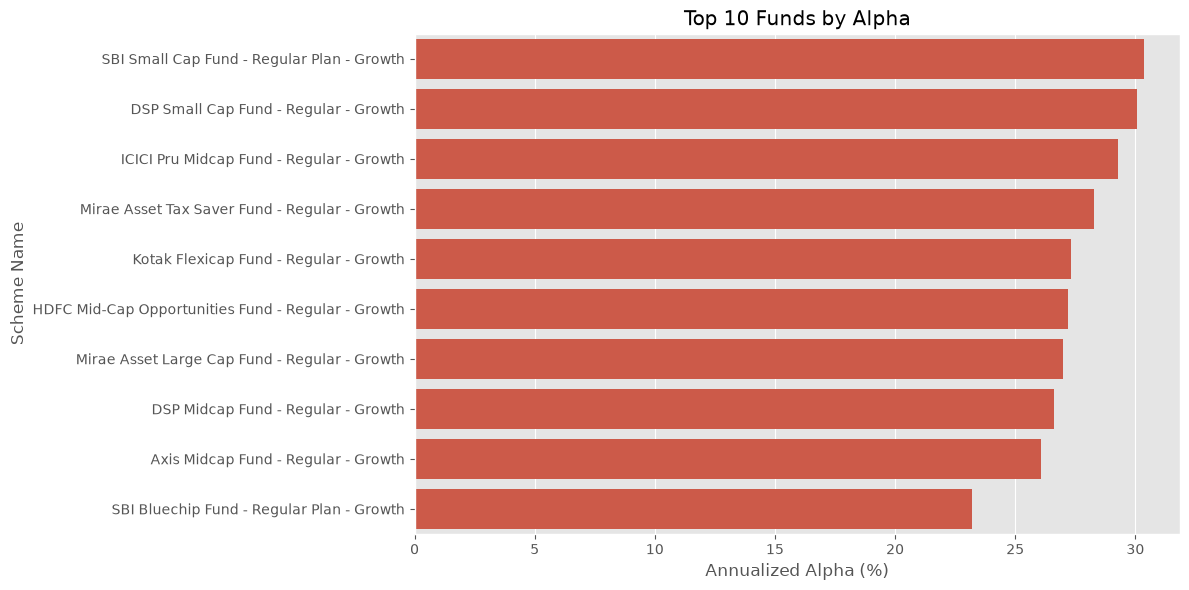

In [57]:
top10_alpha = alpha_beta_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(

    data=top10_alpha,

    x="Alpha",

    y="scheme_name"

)

plt.title("Top 10 Funds by Alpha")

plt.xlabel("Annualized Alpha (%)")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.show()

In [58]:
alpha_beta_df.to_csv(

    "../reports/tables/alpha_beta.csv",

    index=False

)

print("alpha_beta.csv exported successfully.")

alpha_beta.csv exported successfully.


## Business Insights

- Alpha measures the annualized excess return generated by a fund after accounting for benchmark performance.
- Beta measures the sensitivity of a fund to movements in the NIFTY100 index.
- A Beta greater than 1 indicates higher volatility than the benchmark, while a Beta less than 1 indicates lower sensitivity.
- Funds with consistently positive Alpha demonstrate value added beyond market movements.
- Alpha rankings will contribute to the composite Fund Scorecard.

In [59]:
alpha_beta_df.head(10)

,amfi_code,scheme_name,Alpha,Beta,R_Squared,Alpha_Rank
21,119598,SBI Small Cap Fund - Regular Plan - Growth,30.34,-0.023,0.000,1
39,149324,DSP Small Cap Fund - Regular - Growth,30.06,0.011,0.000,2
25,120505,ICICI Pru Midcap Fund - Regular - Growth,29.26,0.001,0.000,3
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,28.27,0.018,0.000,4
30,120843,Kotak Flexicap Fund - Regular - Growth,27.33,-0.023,0.000,5
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.20,0.005,0.000,6
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,26.98,0.024,0.000,7
38,149323,DSP Midcap Fund - Regular - Growth,26.60,-0.003,0.000,8
16,119094,Axis Midcap Fund - Regular - Growth,26.08,-0.066,0.002,9
19,119551,SBI Bluechip Fund - Regular Plan - Growth,23.20,-0.032,0.001,10


In [60]:
print(regression_data.shape)

(46000, 8)


In [61]:
regression_data[
    [
        "date",
        "daily_return",
        "benchmark_return"
    ]
].head(10)

,date,daily_return,benchmark_return
0,2022-01-03,NaN,NaN
1,2022-01-04,0.0012,-0.0135
2,2022-01-05,0.0039,0.0040
3,2022-01-06,-0.0021,-0.0029
4,2022-01-07,-0.0063,0.0062
5,2022-01-10,0.0115,-0.0084
6,2022-01-11,0.0061,0.0049
7,2022-01-12,0.0122,0.0091
8,2022-01-13,-0.0079,0.0037
9,2022-01-14,-0.0057,-0.0141


In [62]:
print(regression_data["benchmark_return"].describe())

count    45960.0000
mean         0.0001
std          0.0081
min         -0.0269
25%         -0.0054
50%         -0.0001
75%          0.0055
max          0.0268
Name: benchmark_return, dtype: float64


In [63]:
print(regression_data["daily_return"].describe())

count    45960.0000
mean         0.0006
std          0.0103
min         -0.0581
25%         -0.0050
50%          0.0003
75%          0.0063
max          0.0647
Name: daily_return, dtype: float64


# 8. Maximum Drawdown (MDD)

Maximum Drawdown measures the largest decline from a historical peak in a mutual fund's NAV.

Formula:

Drawdown = NAV / Running Maximum NAV − 1

Maximum Drawdown = Minimum Drawdown

Funds with lower drawdowns generally exhibit better downside risk management.

In [64]:
# ==========================================================
# Calculate Running Maximum & Drawdown
# ==========================================================

drawdown_data = nav_data.copy()

drawdown_data = drawdown_data.sort_values(
    ["amfi_code", "date"]
)

drawdown_data["running_max"] = (
    drawdown_data
    .groupby("amfi_code")["nav"]
    .cummax()
)

drawdown_data["drawdown"] = (
    drawdown_data["nav"]
    /
    drawdown_data["running_max"]
) - 1

drawdown_data.head()

,amfi_code,date,nav,scheme_name,expense_ratio_pct,benchmark,daily_return,running_max,drawdown
16100,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,1.55,NIFTY 100 TRI,NaN,520.4608,0.0000
16101,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,1.55,NIFTY 100 TRI,-0.0103,520.4608,-0.0103
16102,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,1.55,NIFTY 100 TRI,0.0129,521.7239,0.0000
16103,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,1.55,NIFTY 100 TRI,-0.0114,521.7239,-0.0114
16104,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,1.55,NIFTY 100 TRI,-0.0012,521.7239,-0.0126


In [65]:
# ==========================================================
# Maximum Drawdown for Each Fund
# ==========================================================

mdd_df = (

    drawdown_data

    .groupby(
        ["amfi_code", "scheme_name"]
    )

    .agg(
        Maximum_Drawdown=("drawdown", "min")
    )

    .reset_index()

)

mdd_df.head()

,amfi_code,scheme_name,Maximum_Drawdown
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.2473
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.0431
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.1622
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.1129
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.3545


In [66]:
mdd_df["Maximum_Drawdown"] = (

    mdd_df["Maximum_Drawdown"]

    * 100

).round(2)

mdd_df.head()

,amfi_code,scheme_name,Maximum_Drawdown
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-24.73
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-4.31
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-16.22
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-11.29
4,101207,ABSL Small Cap Fund - Regular - Growth,-35.45


In [67]:
# ==========================================================
# Find Worst Drawdown Date for Each Fund
# ==========================================================

worst_drawdown_dates = (
    drawdown_data.loc[
        drawdown_data.groupby("amfi_code")["drawdown"].idxmin()
    ][
        [
            "amfi_code",
            "scheme_name",
            "date",
            "drawdown"
        ]
    ]
    .rename(
        columns={
            "date": "Worst_Drawdown_Date",
            "drawdown": "Worst_Drawdown_Value"
        }
    )
)

worst_drawdown_dates.head()

,amfi_code,scheme_name,Worst_Drawdown_Date,Worst_Drawdown_Value
16283,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-09-15,-0.2473
14209,100025,HDFC Short Term Debt Fund - Regular - Growth,2023-07-28,-0.0431
12743,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,2022-05-12,-0.1622
392,101206,ABSL Frontline Equity Fund - Regular - Growth,2023-07-05,-0.1129
3435,101207,ABSL Small Cap Fund - Regular - Growth,2026-05-11,-0.3545


In [68]:
# ==========================================================
# Merge Maximum Drawdown Summary
# ==========================================================

mdd_df = mdd_df.merge(
    worst_drawdown_dates[
        [
            "amfi_code",
            "Worst_Drawdown_Date"
        ]
    ],
    on="amfi_code",
    how="left"
)

mdd_df.head()

,amfi_code,scheme_name,Maximum_Drawdown,Worst_Drawdown_Date
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-24.73,2022-09-15
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-4.31,2023-07-28
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-16.22,2022-05-12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-11.29,2023-07-05
4,101207,ABSL Small Cap Fund - Regular - Growth,-35.45,2026-05-11


In [69]:
# ==========================================================
# Rank Funds by Maximum Drawdown
# ==========================================================

mdd_df["Drawdown_Rank"] = (
    mdd_df["Maximum_Drawdown"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

mdd_df = mdd_df.sort_values(
    "Drawdown_Rank"
)

mdd_df.head(10)

,amfi_code,scheme_name,Maximum_Drawdown,Worst_Drawdown_Date,Drawdown_Rank
27,120507,ICICI Pru Liquid Fund - Regular - Growth,-0.10,2025-10-20,1
31,120844,Kotak Liquid Fund - Regular - Growth,-0.12,2024-04-30,2
5,101208,ABSL Liquid Fund - Regular - Growth,-0.16,2023-09-12,3
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-4.31,2023-07-28,4
18,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-4.33,2025-04-01,5
13,118636,Nippon India Gilt Securities Fund - Regular - ...,-8.32,2024-02-09,6
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,-10.86,2022-03-29,7
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,-11.27,2023-10-20,8
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-11.29,2023-07-05,9
12,118635,Nippon India ETF Nifty 50 BeES,-11.65,2022-06-09,10


In [70]:
top10_drawdown = mdd_df.head(10)

top10_drawdown[
    [
        "scheme_name",
        "Maximum_Drawdown",
        "Worst_Drawdown_Date",
        "Drawdown_Rank"
    ]
]

,scheme_name,Maximum_Drawdown,Worst_Drawdown_Date,Drawdown_Rank
27,ICICI Pru Liquid Fund - Regular - Growth,-0.10,2025-10-20,1
31,Kotak Liquid Fund - Regular - Growth,-0.12,2024-04-30,2
5,ABSL Liquid Fund - Regular - Growth,-0.16,2023-09-12,3
1,HDFC Short Term Debt Fund - Regular - Growth,-4.31,2023-07-28,4
18,SBI Magnum Gilt Fund - Regular Plan - Growth,-4.33,2025-04-01,5
13,Nippon India Gilt Securities Fund - Regular - ...,-8.32,2024-02-09,6
6,UTI Nifty 50 Index Fund - Regular - Growth,-10.86,2022-03-29,7
34,Mirae Asset Large Cap Fund - Regular - Growth,-11.27,2023-10-20,8
3,ABSL Frontline Equity Fund - Regular - Growth,-11.29,2023-07-05,9
12,Nippon India ETF Nifty 50 BeES,-11.65,2022-06-09,10


In [71]:
bottom10_drawdown = mdd_df.tail(10)

bottom10_drawdown[
    [
        "scheme_name",
        "Maximum_Drawdown",
        "Worst_Drawdown_Date",
        "Drawdown_Rank"
    ]
]

,scheme_name,Maximum_Drawdown,Worst_Drawdown_Date,Drawdown_Rank
15,Axis Bluechip Fund - Direct - Growth,-21.75,2023-05-22,31
11,Nippon India Small Cap Fund - Regular - Growth,-23.34,2026-02-20,32
29,Kotak Emerging Equity Fund - Regular - Growth,-24.00,2024-10-17,33
0,HDFC Top 100 Fund - Regular Plan - Growth,-24.73,2022-09-15,34
7,UTI Mid Cap Fund - Regular - Growth,-28.00,2026-04-27,35
21,SBI Small Cap Fund - Regular Plan - Growth,-28.71,2025-05-14,36
39,DSP Small Cap Fund - Regular - Growth,-31.17,2025-01-03,37
4,ABSL Small Cap Fund - Regular - Growth,-35.45,2026-05-11,38
17,Axis Small Cap Fund - Regular - Growth,-51.68,2026-05-11,39
22,SBI Small Cap Fund - Direct Plan - Growth,-52.57,2025-10-28,40


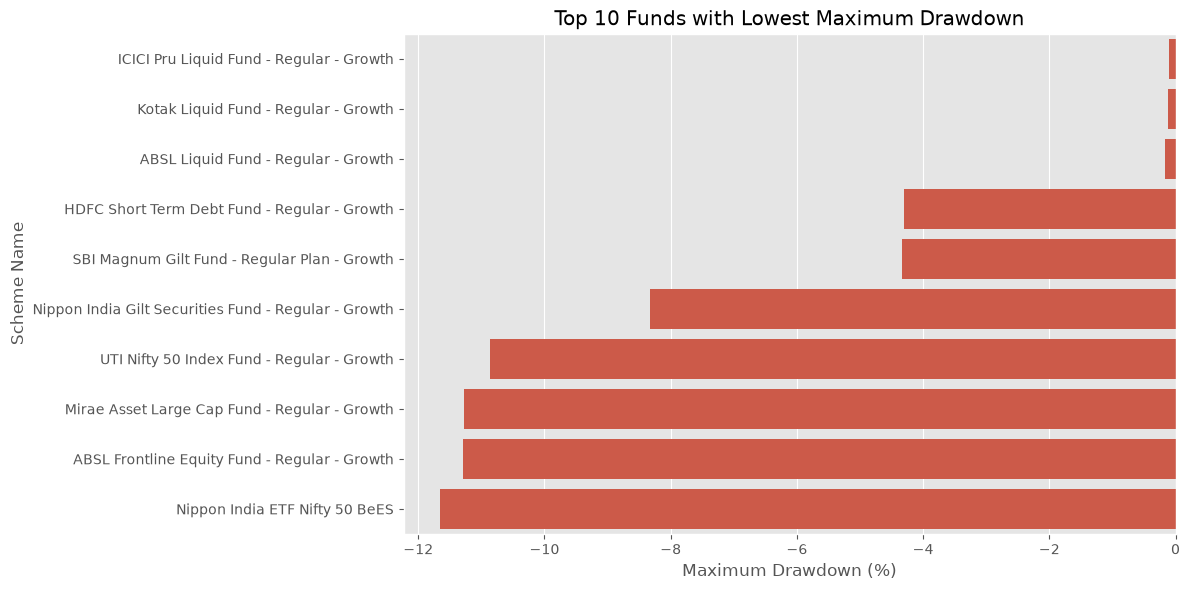

In [72]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_drawdown,
    x="Maximum_Drawdown",
    y="scheme_name"
)

plt.title("Top 10 Funds with Lowest Maximum Drawdown")

plt.xlabel("Maximum Drawdown (%)")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.show()

In [73]:
# ==========================================================
# Export Maximum Drawdown Results
# ==========================================================

mdd_df.to_csv(
    "../reports/tables/maximum_drawdown.csv",
    index=False
)

print("maximum_drawdown.csv exported successfully.")

maximum_drawdown.csv exported successfully.


## Business Insights

- Maximum Drawdown measures the largest historical decline in NAV from its previous peak.
- Debt funds generally exhibited the smallest drawdowns, reflecting their lower volatility.
- Small-cap funds experienced the deepest drawdowns, indicating higher downside risk.
- Maximum Drawdown is included in the final Fund Scorecard to reward funds that preserve investor capital during market declines.

# 9. Fund Scorecard

A composite score is calculated for every mutual fund using multiple performance and risk metrics.

Weights:

- 30% → 3-Year CAGR Rank
- 25% → Sharpe Ratio Rank
- 20% → Alpha Rank
- 15% → Expense Ratio Rank (Lower is Better)
- 10% → Maximum Drawdown Rank (Lower Drawdown is Better)

The final score ranges from **0 to 100**.

In [74]:
# ==========================================================
# Expense Ratio Ranking
# ==========================================================

expense_df = fund_master[
    [
        "amfi_code",
        "scheme_name",
        "expense_ratio_pct"
    ]
].copy()

expense_df["Expense_Rank"] = (
    expense_df["expense_ratio_pct"]
    .rank(
        ascending=True,
        method="dense"
    )
    .astype(int)
)

expense_df.head()

,amfi_code,scheme_name,expense_ratio_pct,Expense_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54,24
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.66,4
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.43,18
3,119599,SBI Small Cap Fund - Direct Plan - Growth,0.72,5
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77,8


In [75]:
# ==========================================================
# Merge All Metrics
# ==========================================================

ranked_cagr_df = cagr_df.copy()

if "Rank_3Y" not in ranked_cagr_df.columns:
    ranked_cagr_df["Rank_3Y"] = ranked_cagr_df["CAGR_3Y"].rank(
        ascending=False,
        method="dense"
    ).astype(int)

scorecard = (

    ranked_cagr_df[
        [
            "amfi_code",
            "scheme_name",
            "Rank_3Y"
        ]
    ]

    .merge(
        sharpe_df[
            [
                "amfi_code",
                "Sharpe_Rank"
            ]
        ],
        on="amfi_code"
    )

    .merge(
        alpha_beta_df[
            [
                "amfi_code",
                "Alpha_Rank"
            ]
        ],
        on="amfi_code"
    )

    .merge(
        expense_df[
            [
                "amfi_code",
                "Expense_Rank"
            ]
        ],
        on="amfi_code"
    )

    .merge(
        mdd_df[
            [
                "amfi_code",
                "Drawdown_Rank"
            ]
        ],
        on="amfi_code"
    )

)

scorecard.head()

,amfi_code,scheme_name,Rank_3Y,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,35,34,39,25,34
1,100025,HDFC Short Term Debt Fund - Regular - Growth,34,38,38,2,4
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,4,7,6,15,20
3,101206,ABSL Frontline Equity Fund - Regular - Growth,9,9,12,29,9
4,101207,ABSL Small Cap Fund - Regular - Growth,39,27,27,23,38


In [76]:
# ==========================================================
# Normalize Rank Columns (0–100)
# ==========================================================

TOTAL_FUNDS = len(scorecard)

def normalize_rank(rank):
    """
    Convert rank into a score between 0 and 100.
    Higher score = Better rank.
    """
    return ((TOTAL_FUNDS - rank) / (TOTAL_FUNDS - 1)) * 100

scorecard["Return_Score"] = scorecard["Rank_3Y"].apply(normalize_rank)

scorecard["Sharpe_Score"] = scorecard["Sharpe_Rank"].apply(normalize_rank)

scorecard["Alpha_Score"] = scorecard["Alpha_Rank"].apply(normalize_rank)

scorecard["Expense_Score"] = scorecard["Expense_Rank"].apply(normalize_rank)

scorecard["Drawdown_Score"] = scorecard["Drawdown_Rank"].apply(normalize_rank)

scorecard.head()

,amfi_code,scheme_name,Rank_3Y,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,35,34,39,25,34,12.8205,15.3846,2.5641,38.4615,15.3846
1,100025,HDFC Short Term Debt Fund - Regular - Growth,34,38,38,2,4,15.3846,5.1282,5.1282,97.4359,92.3077
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,4,7,6,15,20,92.3077,84.6154,87.1795,64.1026,51.2821
3,101206,ABSL Frontline Equity Fund - Regular - Growth,9,9,12,29,9,79.4872,79.4872,71.7949,28.2051,79.4872
4,101207,ABSL Small Cap Fund - Regular - Growth,39,27,27,23,38,2.5641,33.3333,33.3333,43.5897,5.1282


In [77]:
# ==========================================================
# Normalize Rank Columns (0–100)
# ==========================================================

TOTAL_FUNDS = len(scorecard)

def normalize_rank(rank):
    """
    Convert rank into a score between 0 and 100.
    Higher score = Better rank.
    """
    return ((TOTAL_FUNDS - rank) / (TOTAL_FUNDS - 1)) * 100

scorecard["Return_Score"] = scorecard["Rank_3Y"].apply(normalize_rank)

scorecard["Sharpe_Score"] = scorecard["Sharpe_Rank"].apply(normalize_rank)

scorecard["Alpha_Score"] = scorecard["Alpha_Rank"].apply(normalize_rank)

scorecard["Expense_Score"] = scorecard["Expense_Rank"].apply(normalize_rank)

scorecard["Drawdown_Score"] = scorecard["Drawdown_Rank"].apply(normalize_rank)

scorecard.head()

,amfi_code,scheme_name,Rank_3Y,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,35,34,39,25,34,12.8205,15.3846,2.5641,38.4615,15.3846
1,100025,HDFC Short Term Debt Fund - Regular - Growth,34,38,38,2,4,15.3846,5.1282,5.1282,97.4359,92.3077
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,4,7,6,15,20,92.3077,84.6154,87.1795,64.1026,51.2821
3,101206,ABSL Frontline Equity Fund - Regular - Growth,9,9,12,29,9,79.4872,79.4872,71.7949,28.2051,79.4872
4,101207,ABSL Small Cap Fund - Regular - Growth,39,27,27,23,38,2.5641,33.3333,33.3333,43.5897,5.1282


In [78]:
# ==========================================================
# Weighted Composite Score
# ==========================================================

scorecard["Fund_Score"] = (

      0.30 * scorecard["Return_Score"]

    + 0.25 * scorecard["Sharpe_Score"]

    + 0.20 * scorecard["Alpha_Score"]

    + 0.15 * scorecard["Expense_Score"]

    + 0.10 * scorecard["Drawdown_Score"]

).round(2)

scorecard.head()

,amfi_code,scheme_name,Rank_3Y,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,35,34,39,25,34,12.8205,15.3846,2.5641,38.4615,15.3846,15.51
1,100025,HDFC Short Term Debt Fund - Regular - Growth,34,38,38,2,4,15.3846,5.1282,5.1282,97.4359,92.3077,30.77
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,4,7,6,15,20,92.3077,84.6154,87.1795,64.1026,51.2821,81.03
3,101206,ABSL Frontline Equity Fund - Regular - Growth,9,9,12,29,9,79.4872,79.4872,71.7949,28.2051,79.4872,70.26
4,101207,ABSL Small Cap Fund - Regular - Growth,39,27,27,23,38,2.5641,33.3333,33.3333,43.5897,5.1282,22.82


In [79]:
# ==========================================================
# Final Overall Ranking
# ==========================================================

scorecard["Overall_Rank"] = (

    scorecard["Fund_Score"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

scorecard = scorecard.sort_values(

    "Overall_Rank"

)

scorecard.head(10)

,amfi_code,scheme_name,Rank_3Y,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score,Overall_Rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,2,1,7,20,8,97.4359,100.0000,84.6154,51.2821,82.0513,87.05,1
30,120843,Kotak Flexicap Fund - Regular - Growth,7,2,5,19,13,84.6154,97.4359,89.7436,53.8462,69.2308,82.69,2
25,120505,ICICI Pru Midcap Fund - Regular - Growth,5,5,3,14,25,89.7436,89.7436,94.8718,66.6667,38.4615,82.18,3
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,4,7,6,15,20,92.3077,84.6154,87.1795,64.1026,51.2821,81.03,4
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,3,9,13,11,12,94.8718,79.4872,69.2308,74.3590,71.7949,80.51,5
16,119094,Axis Midcap Fund - Regular - Growth,1,10,9,15,28,100.0000,76.9231,79.4872,64.1026,30.7692,77.82,6
19,119551,SBI Bluechip Fund - Regular Plan - Growth,6,4,10,24,17,87.1795,92.3077,76.9231,41.0256,58.9744,76.67,7
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,8,3,4,29,21,82.0513,94.8718,92.3077,28.2051,48.7179,75.90,8
3,101206,ABSL Frontline Equity Fund - Regular - Growth,9,9,12,29,9,79.4872,79.4872,71.7949,28.2051,79.4872,70.26,9
38,149323,DSP Midcap Fund - Regular - Growth,11,6,8,30,22,74.3590,87.1795,82.0513,25.6410,46.1538,68.97,10


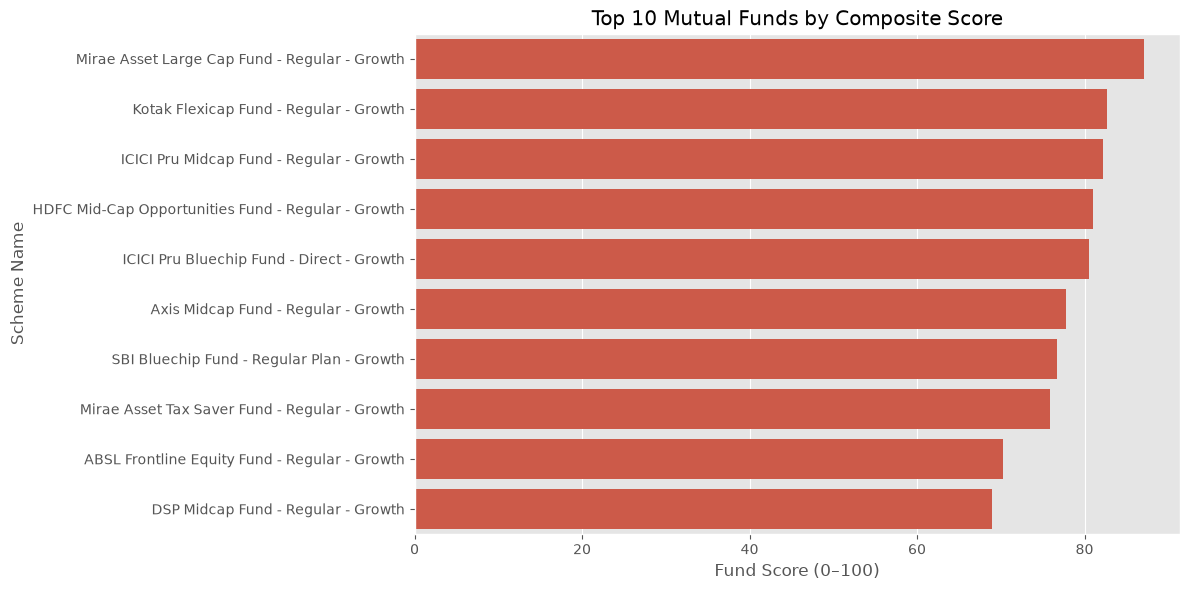

In [80]:
top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

sns.barplot(

    data=top10,

    x="Fund_Score",

    y="scheme_name"

)

plt.title("Top 10 Mutual Funds by Composite Score")

plt.xlabel("Fund Score (0–100)")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.show()

In [81]:
# ==========================================================
# Export Final Scorecard
# ==========================================================

scorecard.to_csv(

    "../reports/tables/fund_scorecard.csv",

    index=False

)

print("fund_scorecard.csv exported successfully.")

fund_scorecard.csv exported successfully.


## Business Insights

- The Fund Scorecard combines return, risk-adjusted performance, alpha generation, expense efficiency, and downside protection into a single composite score.
- Funds with higher scores demonstrate balanced performance across multiple financial metrics rather than excelling in only one area.
- The weighting scheme emphasizes long-term return (30%) and risk-adjusted return (25%), while also rewarding alpha generation, lower costs, and stronger downside protection.
- The composite ranking provides an objective framework for comparing mutual funds across the dataset.

# 10. Benchmark Comparison

This section compares the cumulative performance of the top five mutual funds against the NIFTY50 and NIFTY100 benchmark indices.

Tracking Error is also calculated to measure how closely each fund follows the benchmark.

Formula:

Tracking Error = Std(Fund Return − Benchmark Return) × √252

In [82]:
# ==========================================================
# Select Top 5 Funds
# ==========================================================

top5_codes = scorecard.head(5)["amfi_code"].tolist()

top5_names = scorecard.head(5)["scheme_name"].tolist()

print(top5_names)

['Mirae Asset Large Cap Fund - Regular - Growth', 'Kotak Flexicap Fund - Regular - Growth', 'ICICI Pru Midcap Fund - Regular - Growth', 'HDFC Mid-Cap Opportunities Fund - Regular - Growth', 'ICICI Pru Bluechip Fund - Direct - Growth']


In [83]:
# ==========================================================
# Prepare Benchmark Data
# ==========================================================

benchmark_plot = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
].copy()

benchmark_plot = benchmark_plot.sort_values("date")

In [84]:
# ==========================================================
# Normalize Top 5 Fund NAV
# ==========================================================

top5_nav = nav_data[
    nav_data["amfi_code"].isin(top5_codes)
].copy()

top5_nav = top5_nav.sort_values(
    ["scheme_name", "date"]
)

top5_nav["Normalized_NAV"] = (

    top5_nav

    .groupby("scheme_name")["nav"]

    .transform(

        lambda x: x / x.iloc[0] * 100

    )

)

In [85]:
# ==========================================================
# Normalize Benchmark Values
# ==========================================================

benchmark_plot["Normalized_Index"] = (

    benchmark_plot

    .groupby("index_name")["close_value"]

    .transform(

        lambda x: x / x.iloc[0] * 100

    )

)

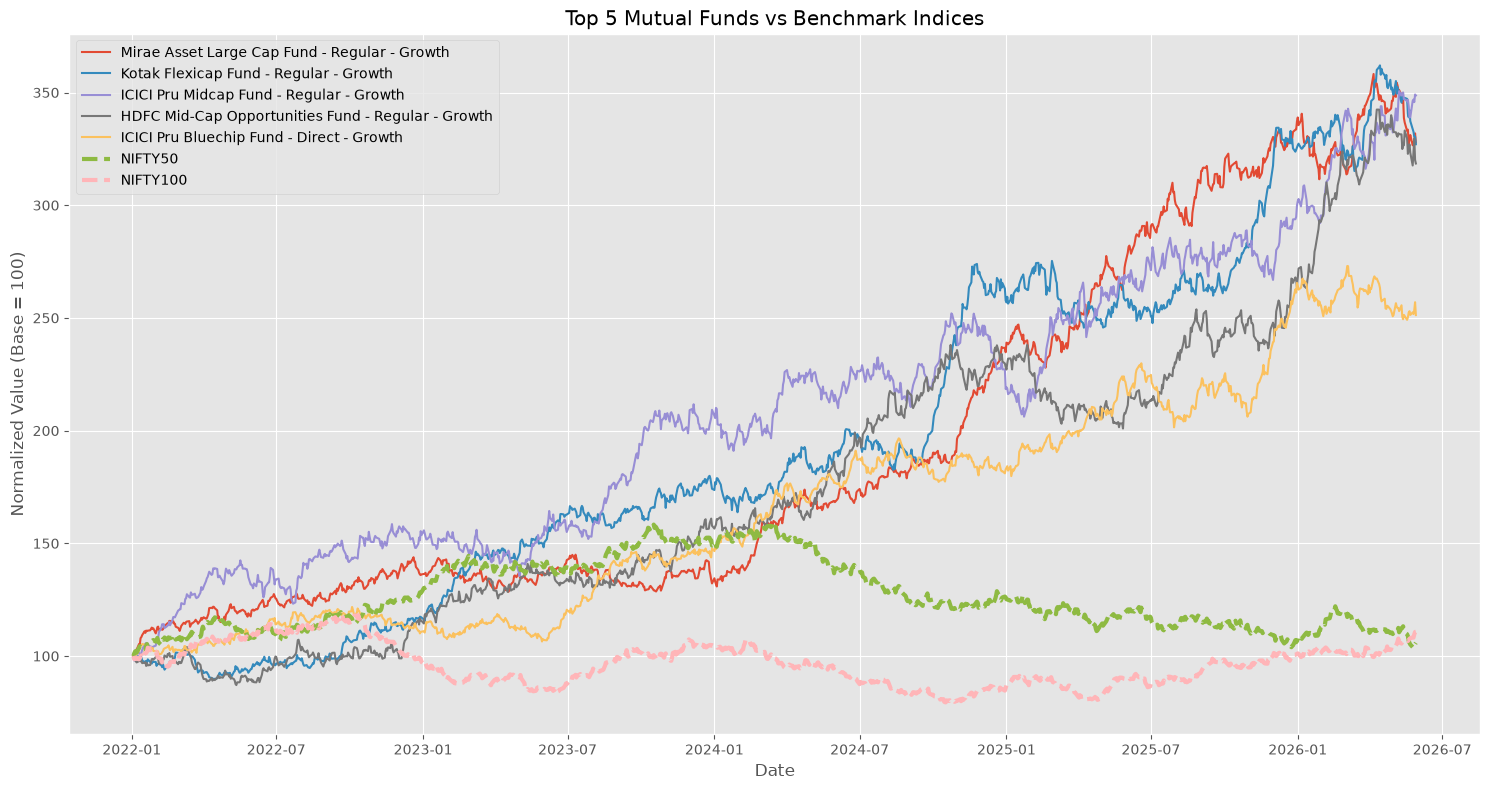

In [86]:
# ==========================================================
# Benchmark Comparison Chart
# ==========================================================

plt.figure(figsize=(15,8))

# Plot Mutual Funds
for fund in top5_names:

    temp = top5_nav[
        top5_nav["scheme_name"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["Normalized_NAV"],
        label=fund
    )

# Plot Benchmarks
for idx in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_plot[
        benchmark_plot["index_name"] == idx
    ]

    plt.plot(
        temp["date"],
        temp["Normalized_Index"],
        linewidth=3,
        linestyle="--",
        label=idx
    )

plt.title("Top 5 Mutual Funds vs Benchmark Indices")

plt.xlabel("Date")

plt.ylabel("Normalized Value (Base = 100)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [87]:
# ==========================================================
# Tracking Error
# ==========================================================

benchmark_returns = (

    benchmark_plot[
        benchmark_plot["index_name"] == "NIFTY100"
    ][
        [
            "date",
            "close_value"
        ]
    ]

    .sort_values("date")

)

benchmark_returns["benchmark_return"] = (

    benchmark_returns["close_value"]

    .pct_change()

)

tracking_results = []

for code in top5_codes:

    fund = nav_data[
        nav_data["amfi_code"] == code
    ].copy()

    merged = fund.merge(

        benchmark_returns,

        on="date"

    )

    merged["tracking_error"] = (

        merged["daily_return"]

        -

        merged["benchmark_return"]

    )

    te = (

        merged["tracking_error"]

        .std()

        * np.sqrt(252)

    )

    tracking_results.append({

        "scheme_name": fund["scheme_name"].iloc[0],

        "Tracking_Error": round(te,4)

    })

tracking_error_df = pd.DataFrame(tracking_results)

tracking_error_df

,scheme_name,Tracking_Error
0,Mirae Asset Large Cap Fund - Regular - Growth,0.1897
1,Kotak Flexicap Fund - Regular - Growth,0.2064
2,ICICI Pru Midcap Fund - Regular - Growth,0.2320
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.2287
4,ICICI Pru Bluechip Fund - Direct - Growth,0.1916


In [88]:
# ==========================================================
# Export Results
# ==========================================================

tracking_error_df.to_csv(
    "../reports/tables/tracking_error.csv",
    index=False
)

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

print("Benchmark comparison exported successfully.")

Benchmark comparison exported successfully.


<Figure size 1200x600 with 0 Axes>

## Business Insights

- The benchmark comparison chart illustrates how the top five mutual funds performed relative to the NIFTY50 and NIFTY100 indices over the analysis period.
- All series were normalized to a base value of 100 to enable direct comparison of growth trends.
- Tracking Error quantifies the deviation of a fund's daily returns from the NIFTY100 benchmark.
- Lower Tracking Error indicates that a fund more closely follows the benchmark, while higher values indicate greater active management.
- Together with the Fund Scorecard, this comparison provides a comprehensive view of both absolute performance and benchmark-relative behavior.

# Conclusion

This analysis evaluated 40 mutual fund schemes using return, risk, benchmark-relative performance, and cost efficiency metrics.

### Key Findings

- Daily return analysis provided the foundation for all subsequent performance metrics.
- CAGR identified funds that consistently generated long-term returns.
- Sharpe Ratio and Sortino Ratio highlighted funds with superior risk-adjusted performance.
- Alpha and Beta quantified benchmark-relative performance using the NIFTY100 index.
- Maximum Drawdown measured downside risk and capital preservation capability.
- The composite Fund Scorecard combined multiple quantitative metrics into a single ranking framework.
- Benchmark comparison and Tracking Error illustrated how closely the top-performing funds followed market indices.

Overall, this project demonstrates a complete mutual fund performance analytics workflow, combining data preprocessing, financial metric computation, statistical analysis, visualization, and business interpretation using Python.